In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dots/DOUGHNUT_OW_fold0_0.5_selected_genomic_windows_centered_results.tsv", sep="\t")
fold0["fold"] = [0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dots/DOUGHNUT_OW_fold1_0.5_selected_genomic_windows_centered_results.tsv", sep="\t")
fold1["fold"] = [1 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dots/DOUGHNUT_OW_fold2_0.5_selected_genomic_windows_centered_results.tsv", sep="\t")
fold2["fold"] = [2 for i in range(len(fold2))]

In [5]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [6]:
len(df)

164

In [7]:
len(df[df["dot_result"] <= 0.0])

12

In [ ]:
df.columns

In [8]:
df = df[df["dot_result"] > 0.0]

In [50]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'dot_result',
       'dot_target', 'dot_init', 'num_edits_slice0', 'num_edits_slice1',
       'GC_seq', 'GC_slice0', 'GC_slice1', 'GC_slice0_edited',
       'GC_slice1_edited', 'init_CTCFs_num_slice0', 'CTCFs_num_slice0',
       'FIMO_sum_slice0', 'FIMO_max_slice0', 'orientation_slice0',
       'positions_slice0', 'init_CTCFs_num_slice1', 'CTCFs_num_slice1',
       'FIMO_sum_slice1', 'FIMO_max_slice1', 'orientation_slice1',
       'positions_slice1', 'orientation', 'init_CTCFs_num', 'CTCFs_num',
       'FIMO_sum', 'FIMO_max', 'dot_diff', 'num_edits', 'set'],
      dtype='object')

In [54]:
df[(df["CTCFs_num_slice0"] == 0) & (df["CTCFs_num_slice1"] == 0)]

,chrom,start,end,fold,PearsonR,flat_start,flat_end,centered_start,centered_end,centered_flat_start,...,orientation_slice1,positions_slice1,orientation,init_CTCFs_num,CTCFs_num,FIMO_sum,FIMO_max,dot_diff,num_edits,set
3,chr3,40978432,42289152,0,0.754782,82.0,182.0,40724480,42035200,206,...,no,(),no,0,0,0.0,0.0,0.228463,1160.0,test
11,chr3,127623168,128933888,0,0.700263,322.0,455.0,127893504,129204224,190,...,no,(),no,1,0,0.0,0.0,0.134677,870.0,test
28,chr5,44525568,45836288,0,0.776065,133.0,273.0,44417024,45727744,186,...,no,(),no,1,0,0.0,0.0,0.338583,1046.0,test
31,chr5,51406848,52717568,0,0.742412,56.0,194.0,51138560,52449280,187,...,no,(),no,0,0,0.0,0.0,0.092946,821.0,test
38,chr5,96811008,98121728,0,0.660858,304.0,455.0,97062912,98373632,181,...,no,(),no,1,0,0.0,0.0,0.464249,1138.0,test
42,chr6,65816576,67127296,0,0.661027,56.0,182.0,65536000,66846720,193,...,no,(),no,0,0,0.0,0.0,-0.005035,1078.0,test
46,chr1,50614272,51924992,1,0.751514,133.0,255.0,50487296,51798016,195,...,no,(),no,0,0,0.0,0.0,0.248810,1076.0,valid
50,chr1,68308992,69619712,1,0.721769,110.0,305.0,68208640,69519360,159,...,no,(),no,2,0,0.0,0.0,0.346874,1107.0,valid
69,chr1,163704832,165015552,1,0.735248,324.0,455.0,163977216,165287936,191,...,no,(),no,1,0,0.0,0.0,0.177849,859.0,valid
76,chr13,28884992,30195712,1,0.698864,56.0,313.0,28737536,30048256,128,...,no,(),no,1,0,0.0,0.0,0.399470,897.0,valid


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df

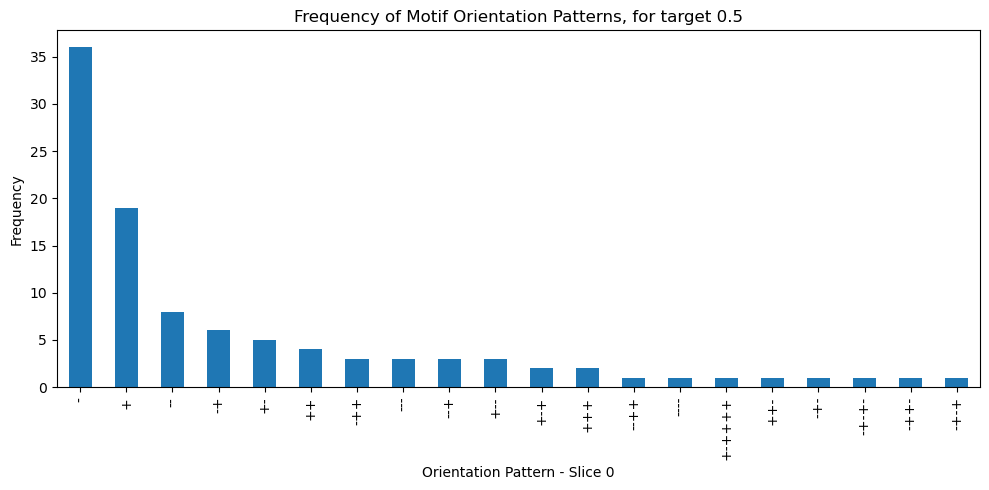

In [10]:
orientation_counts = df[df['orientation_slice0'] != "no"]['orientation_slice0'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern - Slice 0")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target 0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

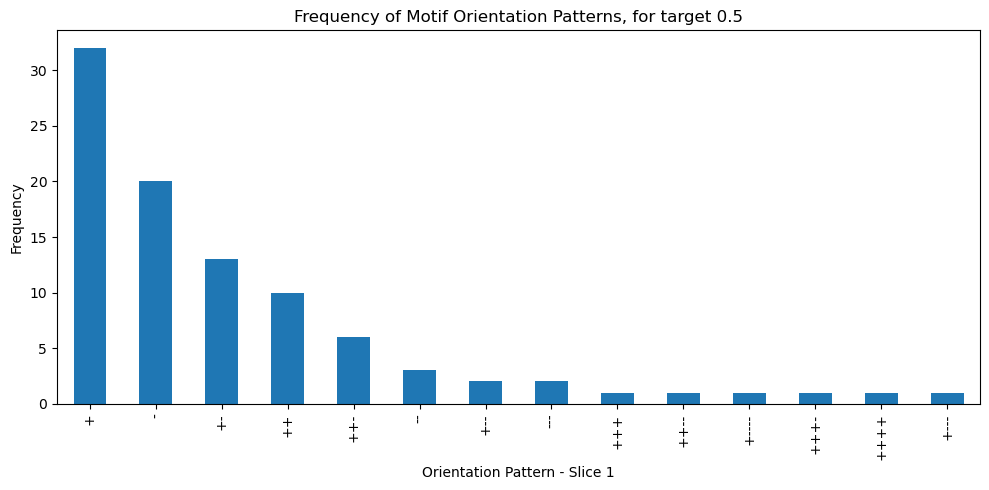

In [11]:
orientation_counts = df[df['orientation_slice1'] != "no"]['orientation_slice1'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern - Slice 1")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target 0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [12]:
df["orientation"] = np.where(
    (df["orientation_slice0"] == "no") | (df["orientation_slice1"] == "no"),
    "no",
    df["orientation_slice0"] + df["orientation_slice1"]
)

In [ ]:
# df["orientation"] = df.apply(
#     lambda row: "no"
#     if row["orientation_slice0"] == "no" and row["orientation_slice1"] == "no"
#     else row["orientation_slice0"].replace("no", "") + row["orientation_slice1"].replace("no", ""),
#     axis=1
# )

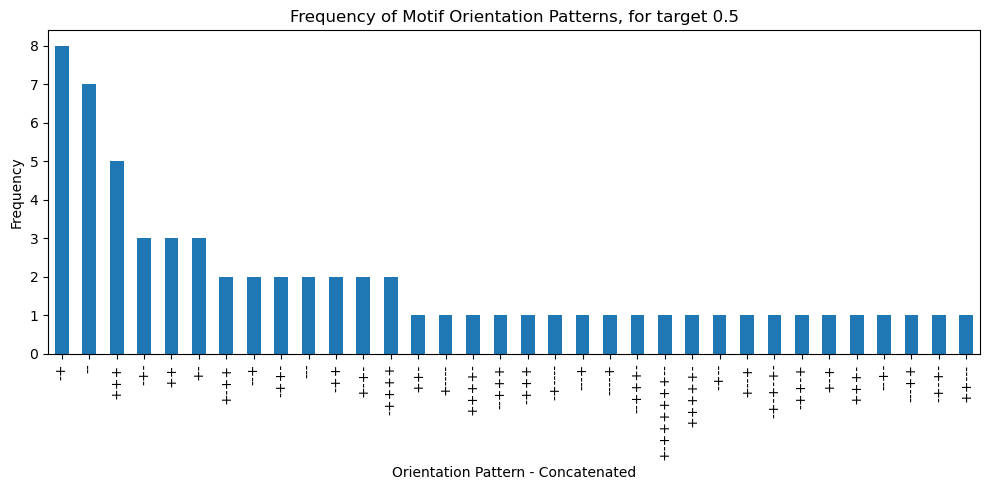

In [13]:
orientation_counts = df[df['orientation'] != "no"]['orientation'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern - Concatenated")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target 0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
df.columns

In [14]:
df_melted = df.melt(value_vars=['dot_init', 'dot_result'], var_name='Type', value_name='dot strength')

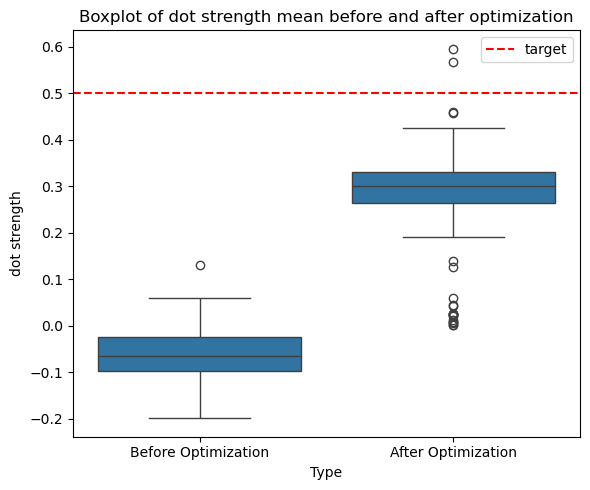

In [15]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Type', y='dot strength', data=df_melted)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='target')
plt.xticks([0, 1], ['Before Optimization', 'After Optimization'])
plt.title('Boxplot of dot strength mean before and after optimization')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
df["init_CTCFs_num"] = df["init_CTCFs_num_slice0"] + df["init_CTCFs_num_slice1"]
df["CTCFs_num"] = df["CTCFs_num_slice0"] + df["CTCFs_num_slice1"]

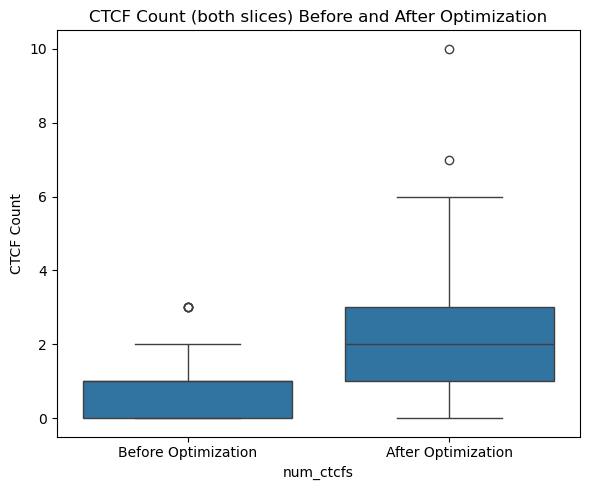

In [17]:
df_box_melted = df.melt(value_vars=['init_CTCFs_num', 'CTCFs_num'],
                            var_name='num_ctcfs', value_name='CTCF Count')

# Rename the categories for clarity
label_map = {
    'init_CTCFs_num': 'Before Optimization',
    'CTCFs_num': 'After Optimization'
}
df_box_melted['num_ctcfs'] = df_box_melted['num_ctcfs'].map(label_map)

# Plotting
plt.figure(figsize=(6, 5))
sns.boxplot(x='num_ctcfs', y='CTCF Count', data=df_box_melted)
plt.title('CTCF Count (both slices) Before and After Optimization')
plt.tight_layout()
plt.show()

In [18]:
from scipy.stats import pearsonr

In [ ]:
df.columns

In [19]:
# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(df['dot_target'], df['dot_result'])

/tmp/SLURM_1156169/ipykernel_1951638/144988765.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(df['dot_target'], df['dot_result'])


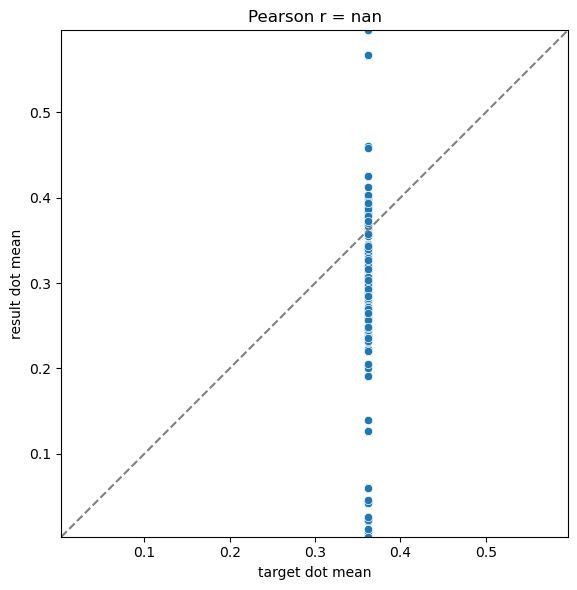

In [20]:
# Determine shared range for both axes
min_val = min(df['dot_target'].min(), df['dot_result'].min())
max_val = max(df['dot_target'].max(), df['dot_result'].max())

# Plotting the scatterplot with equal axis limits and square aspect ratio
plt.figure(figsize=(6, 6))
sns.scatterplot(x='dot_target', y='dot_result', data=df)
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')  # reference diagonal
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f'Pearson r = {r_value:.2f}')
plt.xlabel('target dot mean')
plt.ylabel('result dot mean')
plt.tight_layout()
plt.show()


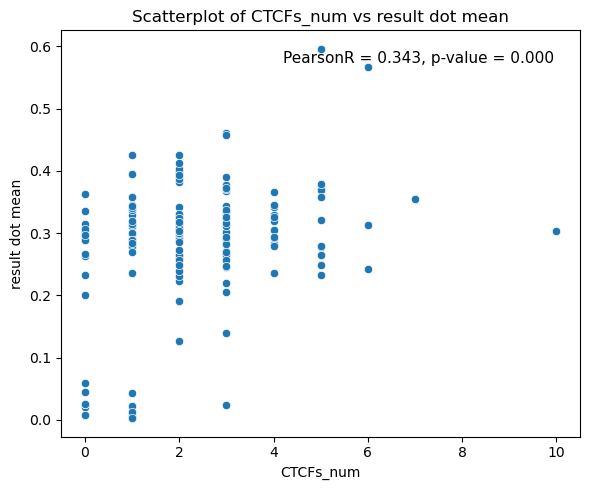

In [21]:

# Compute PearsonR and p-value
r, p = pearsonr(df['CTCFs_num'], df['dot_result'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='CTCFs_num', y='dot_result', data=df)

# Add labels and title
plt.xlabel('CTCFs_num')
plt.ylabel('result dot mean')
plt.title('Scatterplot of CTCFs_num vs result dot mean')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

In [36]:
df["dot_diff"] = df["dot_result"] - df["dot_init"]

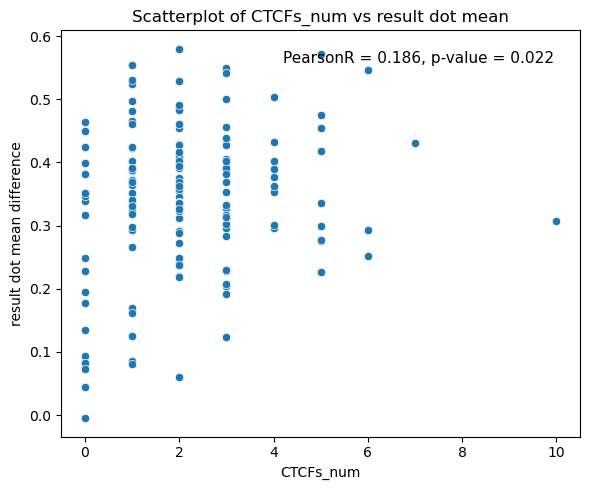

In [37]:
# Compute PearsonR and p-value
r, p = pearsonr(df['CTCFs_num'], df['dot_diff'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='CTCFs_num', y='dot_diff', data=df)

# Add labels and title
plt.xlabel('CTCFs_num')
plt.ylabel('result dot mean difference')
plt.title('Scatterplot of CTCFs_num vs result dot mean')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

In [22]:
df["FIMO_sum"] = df["FIMO_sum_slice0"] + df["FIMO_sum_slice1"]

In [23]:
df["FIMO_max"] = df[["FIMO_max_slice0", "FIMO_max_slice1"]].max(axis=1)

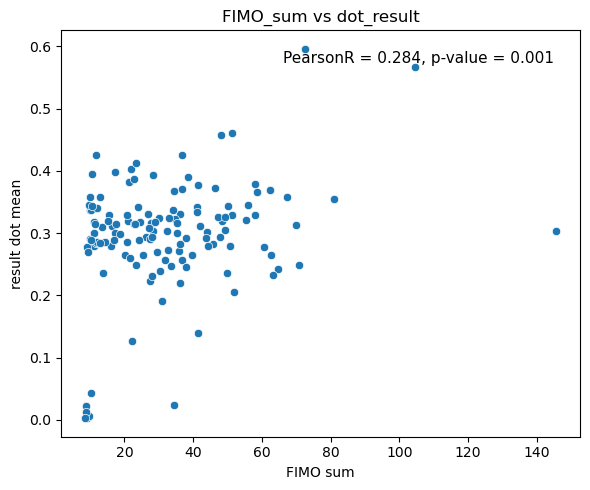

In [24]:
df_part = df[df["FIMO_sum"] > 0]

# Compute PearsonR and p-value
r, p = pearsonr(df_part['FIMO_sum'], df_part['dot_result'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_sum', y='dot_result', data=df_part)

# Add labels and title
plt.xlabel('FIMO sum')
plt.ylabel('result dot mean')
plt.title('FIMO_sum vs dot_result')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

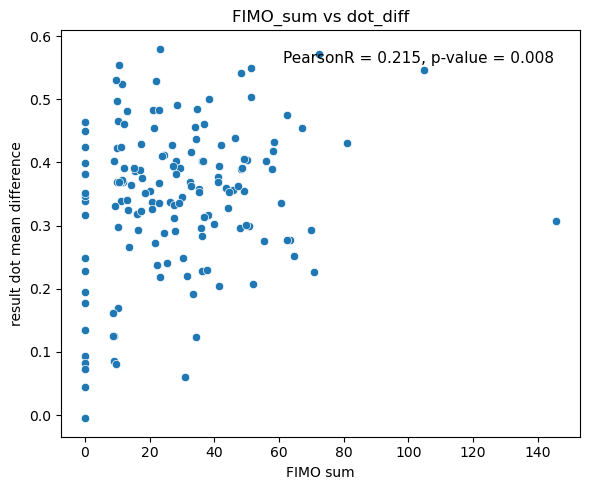

In [39]:
# df_part = df[df["FIMO_sum"] > 0]

# Compute PearsonR and p-value
r, p = pearsonr(df['FIMO_sum'], df['dot_diff'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_sum', y='dot_diff', data=df)

# Add labels and title
plt.xlabel('FIMO sum')
plt.ylabel('result dot mean difference')
plt.title('FIMO_sum vs dot_diff')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

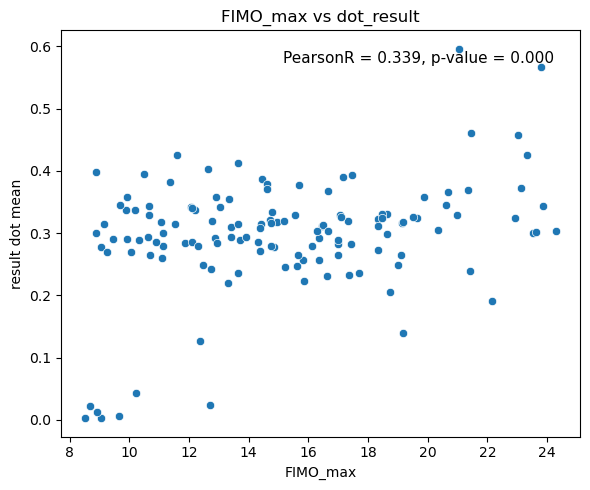

In [28]:
df_part = df[df["FIMO_max"] > 0]

# Compute PearsonR and p-value
r, p = pearsonr(df_part['FIMO_max'], df_part['dot_result'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_max', y='dot_result', data=df_part)

# Add labels and title
plt.xlabel('FIMO_max')
plt.ylabel('result dot mean')
plt.title('FIMO_max vs dot_result')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

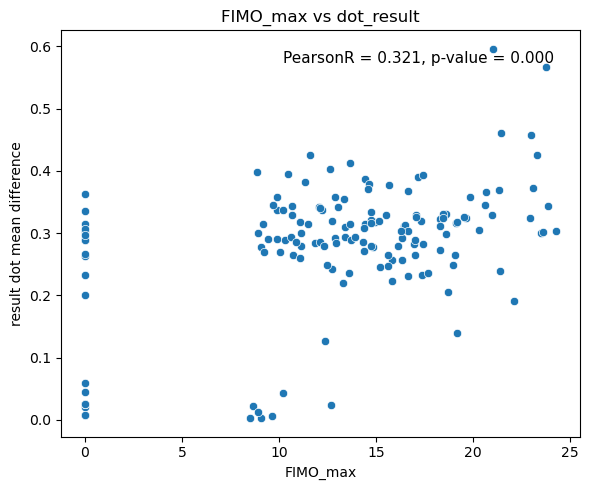

In [40]:
# Compute PearsonR and p-value
r, p = pearsonr(df['FIMO_max'], df['dot_diff'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_max', y='dot_result', data=df)

# Add labels and title
plt.xlabel('FIMO_max')
plt.ylabel('result dot mean difference')
plt.title('FIMO_max vs dot_result')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

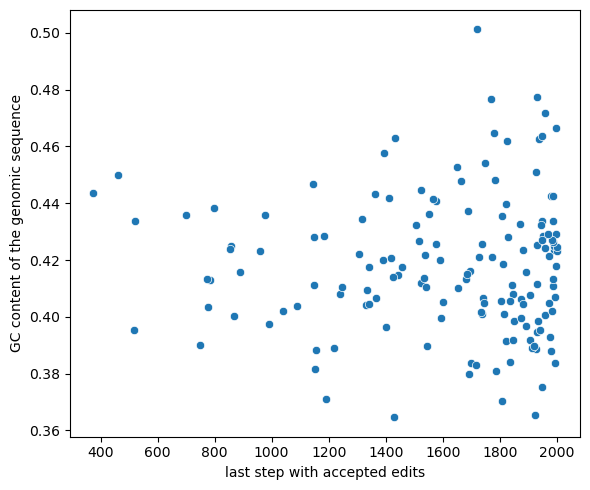

In [29]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='last_accepted_step',
    y='GC_seq',
    data=df
)
plt.xlabel('last step with accepted edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [30]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'dot_result',
       'dot_target', 'dot_init', 'num_edits_slice0', 'num_edits_slice1',
       'GC_seq', 'GC_slice0', 'GC_slice1', 'GC_slice0_edited',
       'GC_slice1_edited', 'init_CTCFs_num_slice0', 'CTCFs_num_slice0',
       'FIMO_sum_slice0', 'FIMO_max_slice0', 'orientation_slice0',
       'positions_slice0', 'init_CTCFs_num_slice1', 'CTCFs_num_slice1',
       'FIMO_sum_slice1', 'FIMO_max_slice1', 'orientation_slice1',
       'positions_slice1', 'orientation', 'init_CTCFs_num', 'CTCFs_num',
       'FIMO_sum', 'FIMO_max', 'dot_diff'],
      dtype='object')

In [31]:
df["num_edits"] = df["num_edits_slice0"] + df["num_edits_slice1"] 

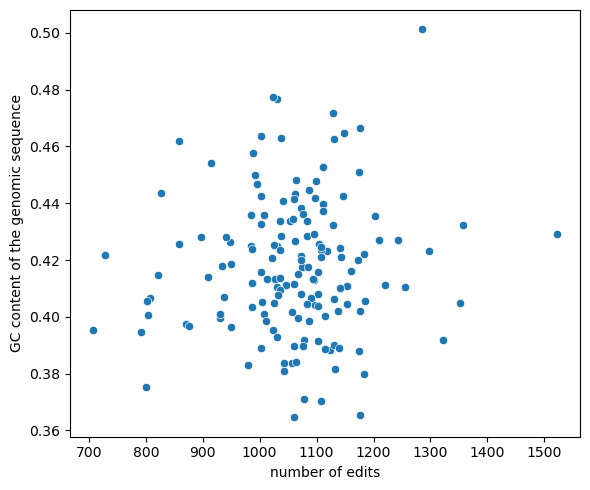

In [32]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='num_edits',
    y='GC_seq',
    data=df
)

plt.xlabel('number of edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [41]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'dot_result',
       'dot_target', 'dot_init', 'num_edits_slice0', 'num_edits_slice1',
       'GC_seq', 'GC_slice0', 'GC_slice1', 'GC_slice0_edited',
       'GC_slice1_edited', 'init_CTCFs_num_slice0', 'CTCFs_num_slice0',
       'FIMO_sum_slice0', 'FIMO_max_slice0', 'orientation_slice0',
       'positions_slice0', 'init_CTCFs_num_slice1', 'CTCFs_num_slice1',
       'FIMO_sum_slice1', 'FIMO_max_slice1', 'orientation_slice1',
       'positions_slice1', 'orientation', 'init_CTCFs_num', 'CTCFs_num',
       'FIMO_sum', 'FIMO_max', 'dot_diff', 'num_edits', 'set'],
      dtype='object')

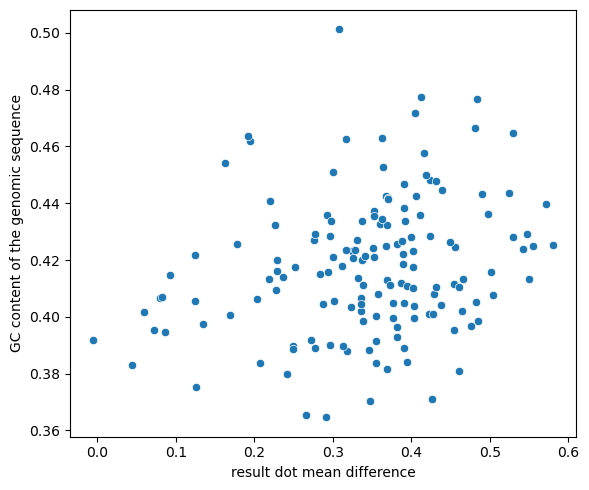

In [42]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='dot_diff',
    y='GC_seq',
    data=df
)

plt.xlabel('result dot mean difference')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()


In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

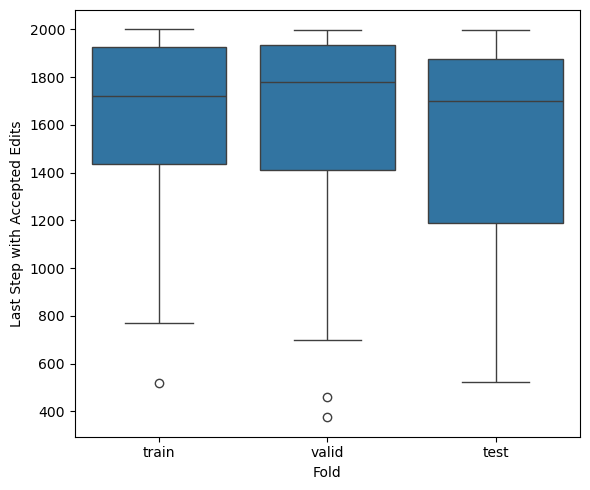

In [34]:
fold_map = {0: 'test', 1: 'valid', 2: 'train'}
df['set'] = df['fold'].map(fold_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='last_accepted_step', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Last Step with Accepted Edits')
plt.tight_layout()
plt.show()

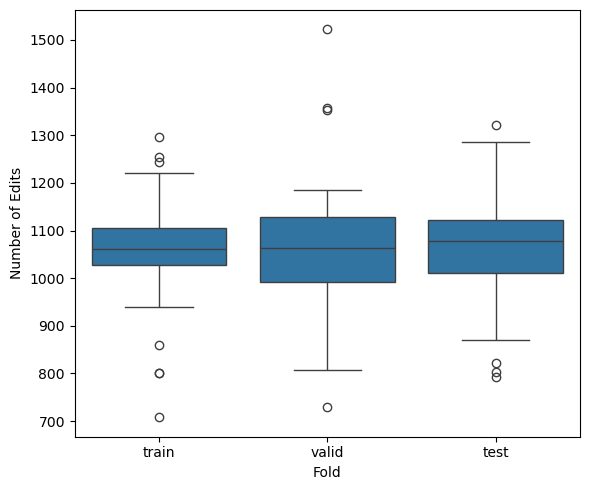

In [35]:
# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='num_edits', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Number of Edits')
plt.tight_layout()
plt.show()

In [43]:
from scipy.stats import ttest_rel

In [ ]:
df.columns

In [44]:
t_stat, p_val = ttest_rel(df['GC_slice0'], df['GC_slice0_edited'])

In [45]:
t_stat, p_val

(-18.749135884290027, 2.904986376295189e-41)

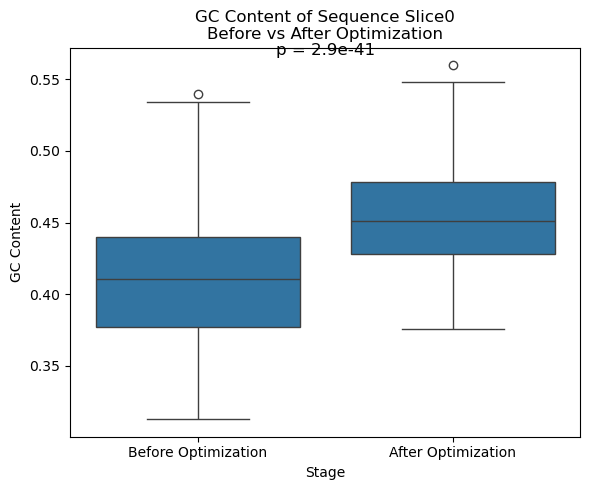

In [46]:
# Melt the DataFrame for plotting
df_gc_melted = df.melt(value_vars=['GC_slice0', 'GC_slice0_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice0': 'Before Optimization',
    'GC_slice0_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice0\nBefore vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [47]:
t_stat, p_val = ttest_rel(df['GC_slice1'], df['GC_slice1_edited'])

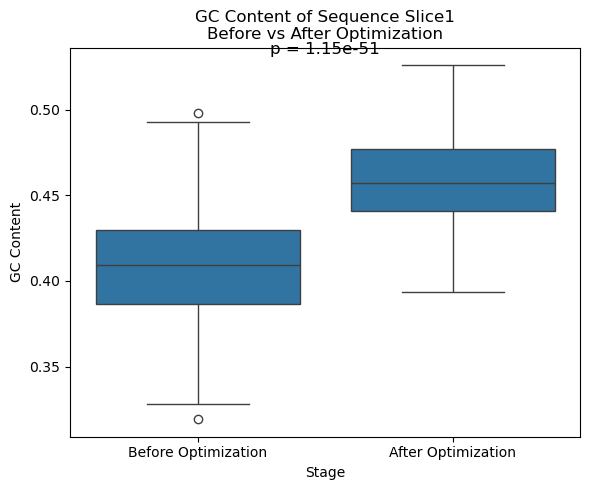

In [48]:
# Melt the DataFrame for plotting
df_gc_melted = df.melt(value_vars=['GC_slice1', 'GC_slice1_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice1': 'Before Optimization',
    'GC_slice1_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice1\nBefore vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()